# Social Network Extraction & Analysis

Demo of the `SocialNetworkTask` and `analysis.social_networks` module.

In [ ]:
from largeliterarymodels.analysis.social_networks import SocialNetwork
import pandas as pd
import lltk
pd.options.display.max_colwidth=None

In [175]:
C=lltk.load('chadwyck')
# C.meta[C.meta.title.str.lower().str.contains('mad world')]

In [176]:
text = C['Early_English_Prose_Fiction/ee19010.01']
text.meta

{'_id': '_chadwyck/Early_English_Prose_Fiction/ee19010.01',
 '_corpus': 'chadwyck',
 'id': 'Early_English_Prose_Fiction/ee19010.01',
 'author': 'Breton, Nicholas, 1545?-1626?',
 'author_norm': 'breton',
 'corpus': 'chadwyck',
 'fn_raw': 'Early_English_Prose_Fiction/ee19010.01.new',
 'genre': 'Fiction',
 'genre_corpus': 'Fiction',
 'genre_enriched_source': 'corpus',
 'genre_raw': 'Fiction',
 'idref': 'Z200026050',
 'lang': 'en',
 'medium': 'Fiction',
 'name': 'Title Page',
 'nation': 'British',
 'path_freqs': 'chadwyck/freqs/Early_English_Prose_Fiction/ee19010.01.json',
 'pub': 'Printed by R. Raworth, for I. S.',
 'subcorpus': 'Early_English_Prose_Fiction',
 'title': 'A Mad VVorld my masters (1635)',
 'title_norm': "a mad world my Master's",
 'type': 'BOOK',
 'year': 1635,
 'year_orig': 1635}

In [177]:
def get_path(text):
    import os
    tdir = text.task_dir('social_network')
    for fn in os.listdir(tdir):
        if fn.endswith('.json'):
            return os.path.join(tdir,fn)

In [178]:
path = get_path(text)

In [179]:
# sn = SocialNetwork('../data/archived/social_network_chadwyck_Nineteenth-Century_Fiction_ncf0204.01_qwen36-27b.json', title='Emma')
# sn = SocialNetwork('../data/archived/social_network_chadwyck_Eighteenth-Century_Fiction_haywood.13_qwen36-27b.json', title='Masqueraders')
# sn = SocialNetwork('../data/archived/social_network_chadwyck_Eighteenth-Century_Fiction_defoe.06_qwen36-27b.json', title='Moll')
# sn = SocialNetwork('../data/archived/social_network_chadwyck_Nineteenth-Century_Fiction_ncf22503.02_qwen36-27b.json', title='Bleak House')
# sn = SocialNetwork('../data/archived/social_network_chadwyck_Early_English_Prose_Fiction_ee51011z.01_qwen36-27b.json', title='English Rogue')
# sn = SocialNetwork('../data/social_network_chadwyck_Early_English_Prose_Fiction_ee92010.01_qwen36-27b.json', title='Arcadia')
# sn = SocialNetwork('../data/social_network_chadwyck_Early_English_Prose_Fiction_ee71010.01_qwen36-27b.json', title='Lenten Stuffe')
# sn = SocialNetwork('/Volumes/chambers/lltk_data/corpora/chadwyck/tasks/social_network/Early_English_Prose_Fiction/ee67011.02/qwen36-27b.json', title='??')
sn = SocialNetwork(path, title=text.title)
sn.summary()                          # print key stats

A Mad VVorld my masters (1635)
  Characters: 33
  Relations:  76
  Events:     87
  Dialogue:   55
  Locations:  36
  Passages:   95
  Density:    0.066
  Clustering: 0.242


In [182]:
sn.top_characters(10)                 # DataFrame by degree

,id,name,gender,class,degree
0,C13,The Narrator (Moll),female,gentlewoman,9
1,C28,Fantiro,male,prince,7
2,C26,Ordillo,male,duke,6
3,C02,Dorindo,male,traveler,5
4,C22,Firento Sanelli,male,duke,5
5,C10,Captain,male,military,3
6,C16,The Shepherd's Wife,female,peasant,3
7,C30,Ordillo's Brother,male,noble,3
8,C32,Mario Duronte,male,merchant,3
9,C35,Signor Sperto,male,courtier,3


In [183]:
sn.top_characters(10, by='betweenness')

,id,name,gender,class,betweenness
0,C13,The Narrator (Moll),female,gentlewoman,0.1361
1,C02,Dorindo,male,traveler,0.0927
2,C10,Captain,male,military,0.0907
3,C28,Fantiro,male,prince,0.0376
4,C22,Firento Sanelli,male,duke,0.0262
5,C26,Ordillo,male,duke,0.0255
6,C32,Mario Duronte,male,merchant,0.0060
7,C30,Ordillo's Brother,male,noble,0.0020
8,C24,Penillo,male,prince,0.0013
9,C16,The Shepherd's Wife,female,peasant,0.0010


In [184]:
sn.character_df()                     # full character table with intro_text

,id,name,gender,class,aliases,intro_text,descriptions,degree
12,C13,The Narrator (Moll),female,gentlewoman,,"It was my unhappie Parents hap, (among many other) to fall into the hands of these bloudie fellowes... spurned me at there feete, spet in my face, slong me out of doores to goe seeke my fortune.","Infant | poore Girle | foolish Gyrle | young Gentlewoman | seely Wench | in silke, and fine | braue",9
26,C28,Fantiro,male,prince,,"her sonne, named Fantiro... a man of excellent partes, both for bodie, and mind",excellent partes | valour | vertue | Souldiers Dictionarie | Courtiers Looking glasse,7
24,C26,Ordillo,male,duke,,"another Duke, who dwelt in the Ilandes of Cotasie... This Duke had to name Ordillo, a man famous for much worth as well in wit as valour",famous for much worth | wit | valour | Lambe at home | Lyon abroad | wisedome | clemencie,6
21,C22,Firento Sanelli,male,duke,,"In the Ilandes of Balino, neere vnto the Citie of Dolno, there liued a great Duke named Firento Sanelli, a great Lord I saie, for that he was great both in honor and possessions",great Duke | great Lord | wise | honorable | valiant | couetous | vertuous,5
1,C02,Dorindo,male,traveler,,mine honest Dorindo,honest | weather-beaten | handsome man,5
32,C35,Signor Sperto,male,courtier,,"one, who hauing more wealth then honour, thought to buy loue with drosse, which ilfauoured dogge, vnworthie to bee called a man",ilfauoured dogge | vnworthie to bee called a man | hobby horse of a man | slouch of a slouen | wicked wretch | squinte eie | halfe nose | wrie mouth,3
29,C32,Mario Duronte,male,merchant,,"the Merchant that hath fraight and victualed her is one Mario Duronte, a friend of mine",Merchant | friend of the Villain,3
27,C30,Ordillo's Brother,male,noble,,"his vncle brother to the Duke, and one of his priuie Counsalle, that to aduance his owne children, he cared not what became of his brothers sonne",vncle brother to the Duke | priuie Counsalle | wicked creature,3
9,C10,Captain,male,military,,a gallant Captaine that was to doe a piece of seruice upon a City of the Turkes,gallant Captaine | gallant souldier | envious | cruel,3
15,C16,The Shepherd's Wife,female,peasant,,a crabbed old Woman,crabbed old Woman | poore woman | good mother,3


In [185]:
sn.relation_counts()                  # Counter

Counter({'spouse_of': 9,
         'served_by': 9,
         'sibling_of': 8,
         'serves': 6,
         'patron_of': 6,
         'attracted_to': 6,
         'friend_of': 5,
         'parent_of': 5,
         'enemy_of': 5,
         'courted': 3,
         'rejected': 3,
         'betrayed': 2,
         'confidante_of': 2,
         'child_of': 2,
         'inherited_from': 1,
         'allied_with': 1,
         'deceived': 1})

In [186]:
sn.locations()                        # DataFrame

,n_events,n_characters,characters,first_passage,last_passage
location,,,,,
Cotasie,7,5,"[C31, C28, C24, C26, C32]",P056,P086
Balino,3,3,"[C24, C22, C35]",P054,P081
street,2,1,[C02],P003,P006
the wilderness,2,2,"[C15, C13]",P024,P025
Cotasie camp,2,2,"[C25, C26]",P090,P091
Dolno,2,2,"[C28, C33]",P058,P058
Rouen,2,1,[C01],P012,P012
Duke Ordillo's tent,2,2,"[C24, C25]",P093,P093
Field,2,1,[C20],P048,P049


In [187]:
sn.story()


[P000-P009]
  Lorenzo (C01) meets his friend Dorindo (C02), who recounts his travels. Dorindo describes being shipwrecked and mistaking a Mock-beggar house for a nobleman's home, encountering a servant (C03) and a fool (C04). He then meets a miserly merchant (C05) who tries to buy his pearls cheap. In the city, he meets a distant relative (C06) and a tailor (C07) dominated by his wife (C08). Dorindo courts a covetous gentlewoman (C09) and serves under a cruel captain (C10). Finally, he meets a vicar (C11) and a wise plain fellow (C12) who hosts him.

[P010-P019]
  Dorindo (C02) departs from the Plain Fellow (C12) after receiving moral counsel. Lorenzo (C01) then recounts his own travels to Dorindo. He describes being constantly misunderstood ('taken') in various roles: first as a courtier, then fleeing to Rouen where he posed as a physician. He traveled to Antwerp but was captured by pirates. Afterward, he courted a prostitute, squandering his wealth. He then attempted to pass as a la

<Axes: title={'center': 'A Mad VVorld my masters (1635)\n33 nodes, 38 edges, density=0.036'}>

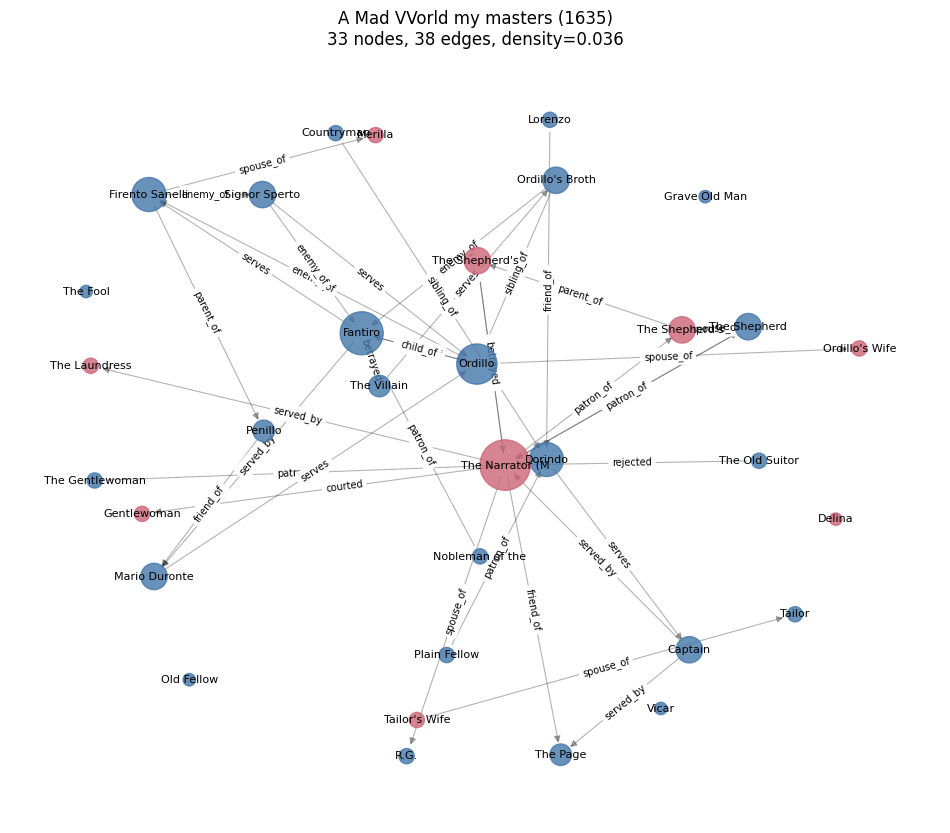

In [188]:
# Single graphs (accept ax= for composing figures)
sn.plot_relations(color_by='gender',k=1)  # also 'class', 'degree', 'betweenness', or custom dict

<Axes: title={'center': 'A Mad VVorld my masters (1635): events (25 edges)'}>

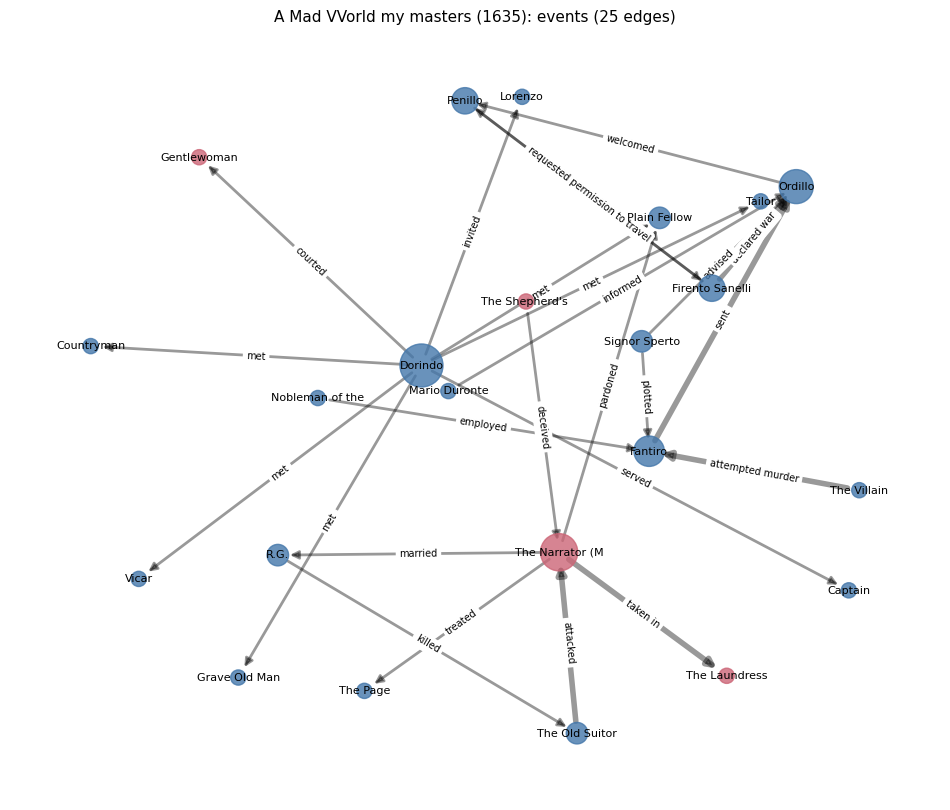

In [189]:
sn.plot_events(k=1)

<Axes: title={'center': 'A Mad VVorld my masters (1635): dialogue (27 edges)'}>

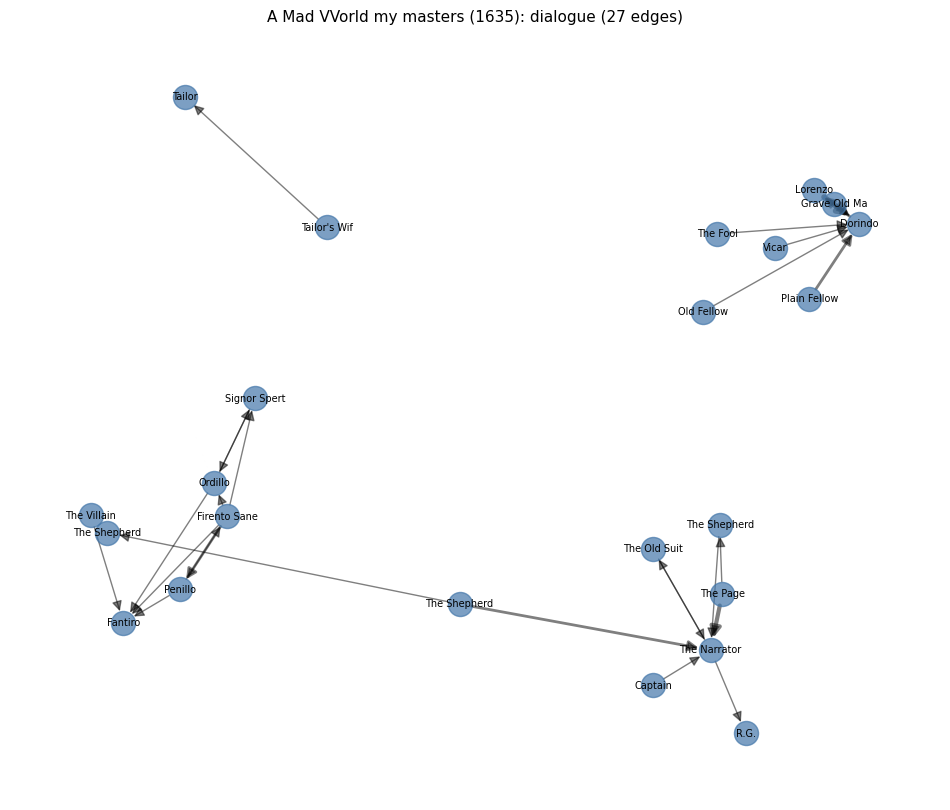

In [190]:
sn.plot_dialogue(label_edges=False, k=.35)

<Axes: title={'center': 'A Mad VVorld my masters (1635): all interactions\n32 chars, 61 edges (38 rel, 25 event, 27 dialogue)'}>

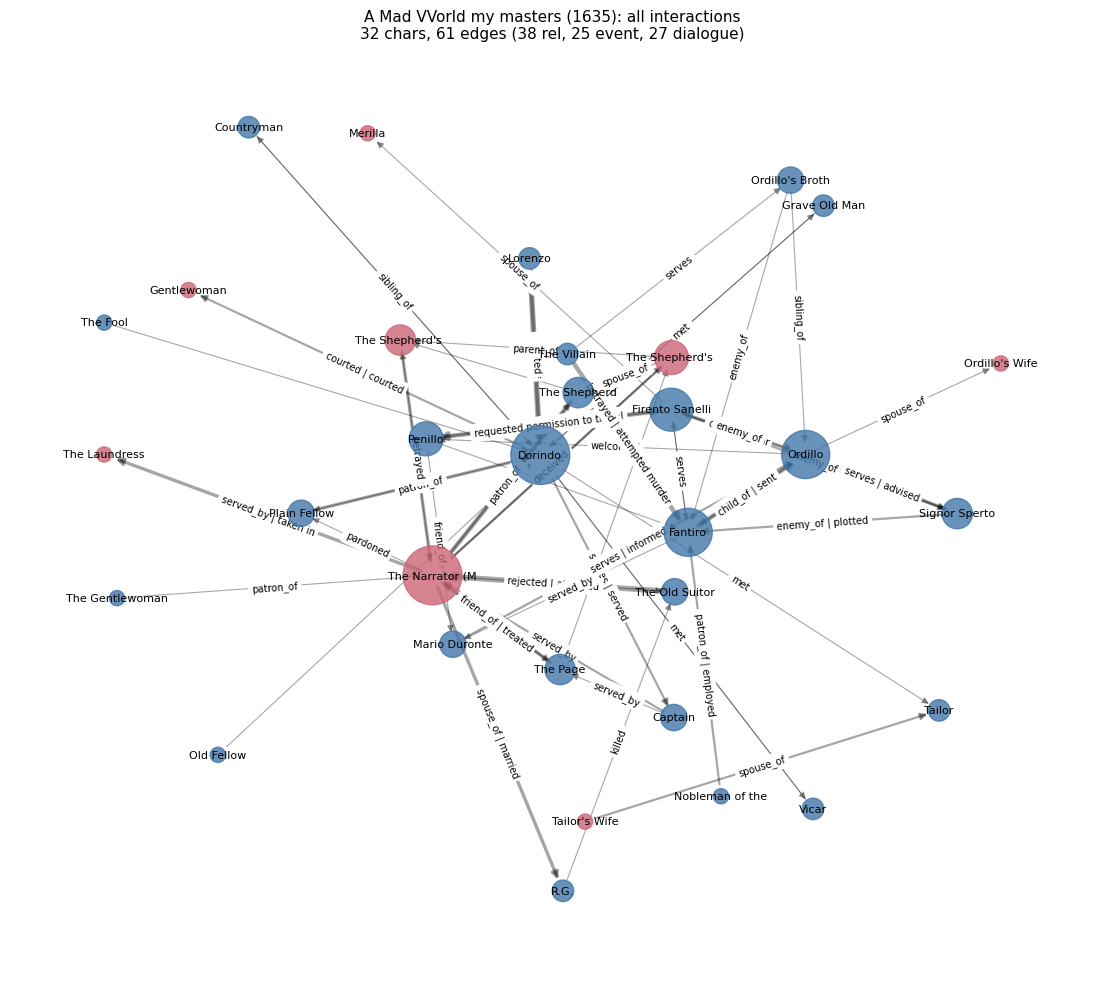

In [191]:
sn.plot_all(k=1, color_by='gender')

<Axes: title={'center': 'A Mad VVorld my masters (1635): The Narrator (Moll) trajectory (9 events)'}, xlabel='Passage number'>

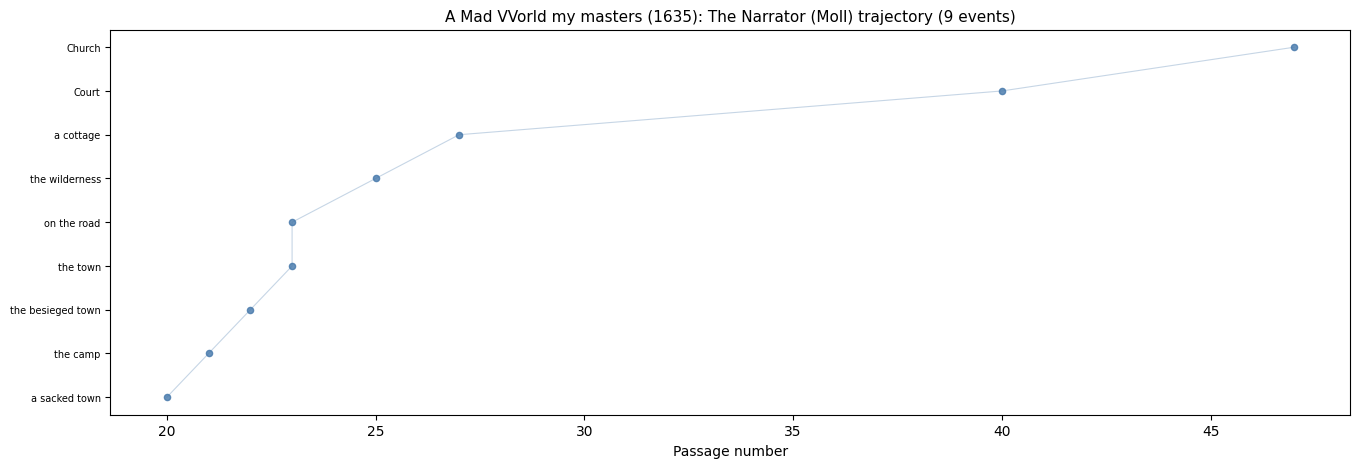

In [192]:
sn.plot_trajectory()                  # auto-picks protagonist by degree

In [193]:
# sn.plot_trajectory('C01')             # specific character

<Axes: title={'center': 'A Mad VVorld my masters (1635): relation types'}, xlabel='count'>

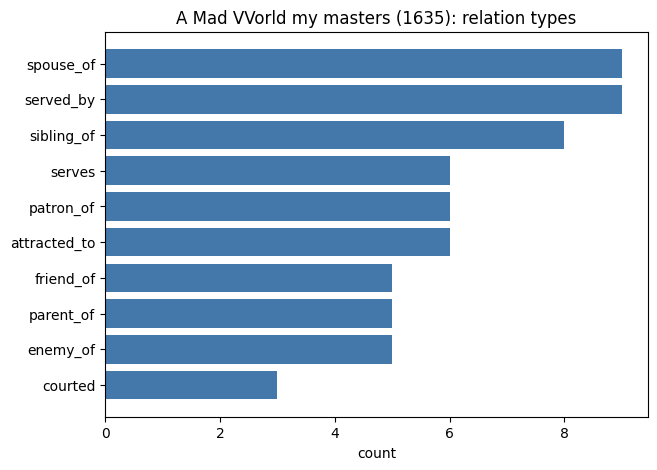

In [194]:
sn.plot_relation_types()              # horizontal bar chart

<Axes: title={'center': 'A Mad VVorld my masters (1635): top event verbs'}, xlabel='count'>

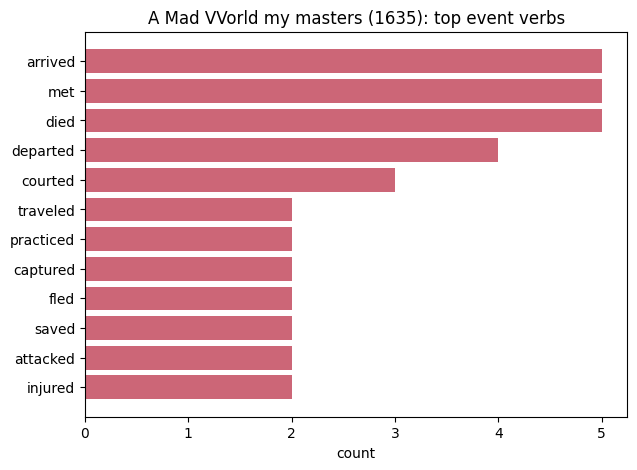

In [195]:
sn.plot_event_verbs()                 # horizontal bar chart

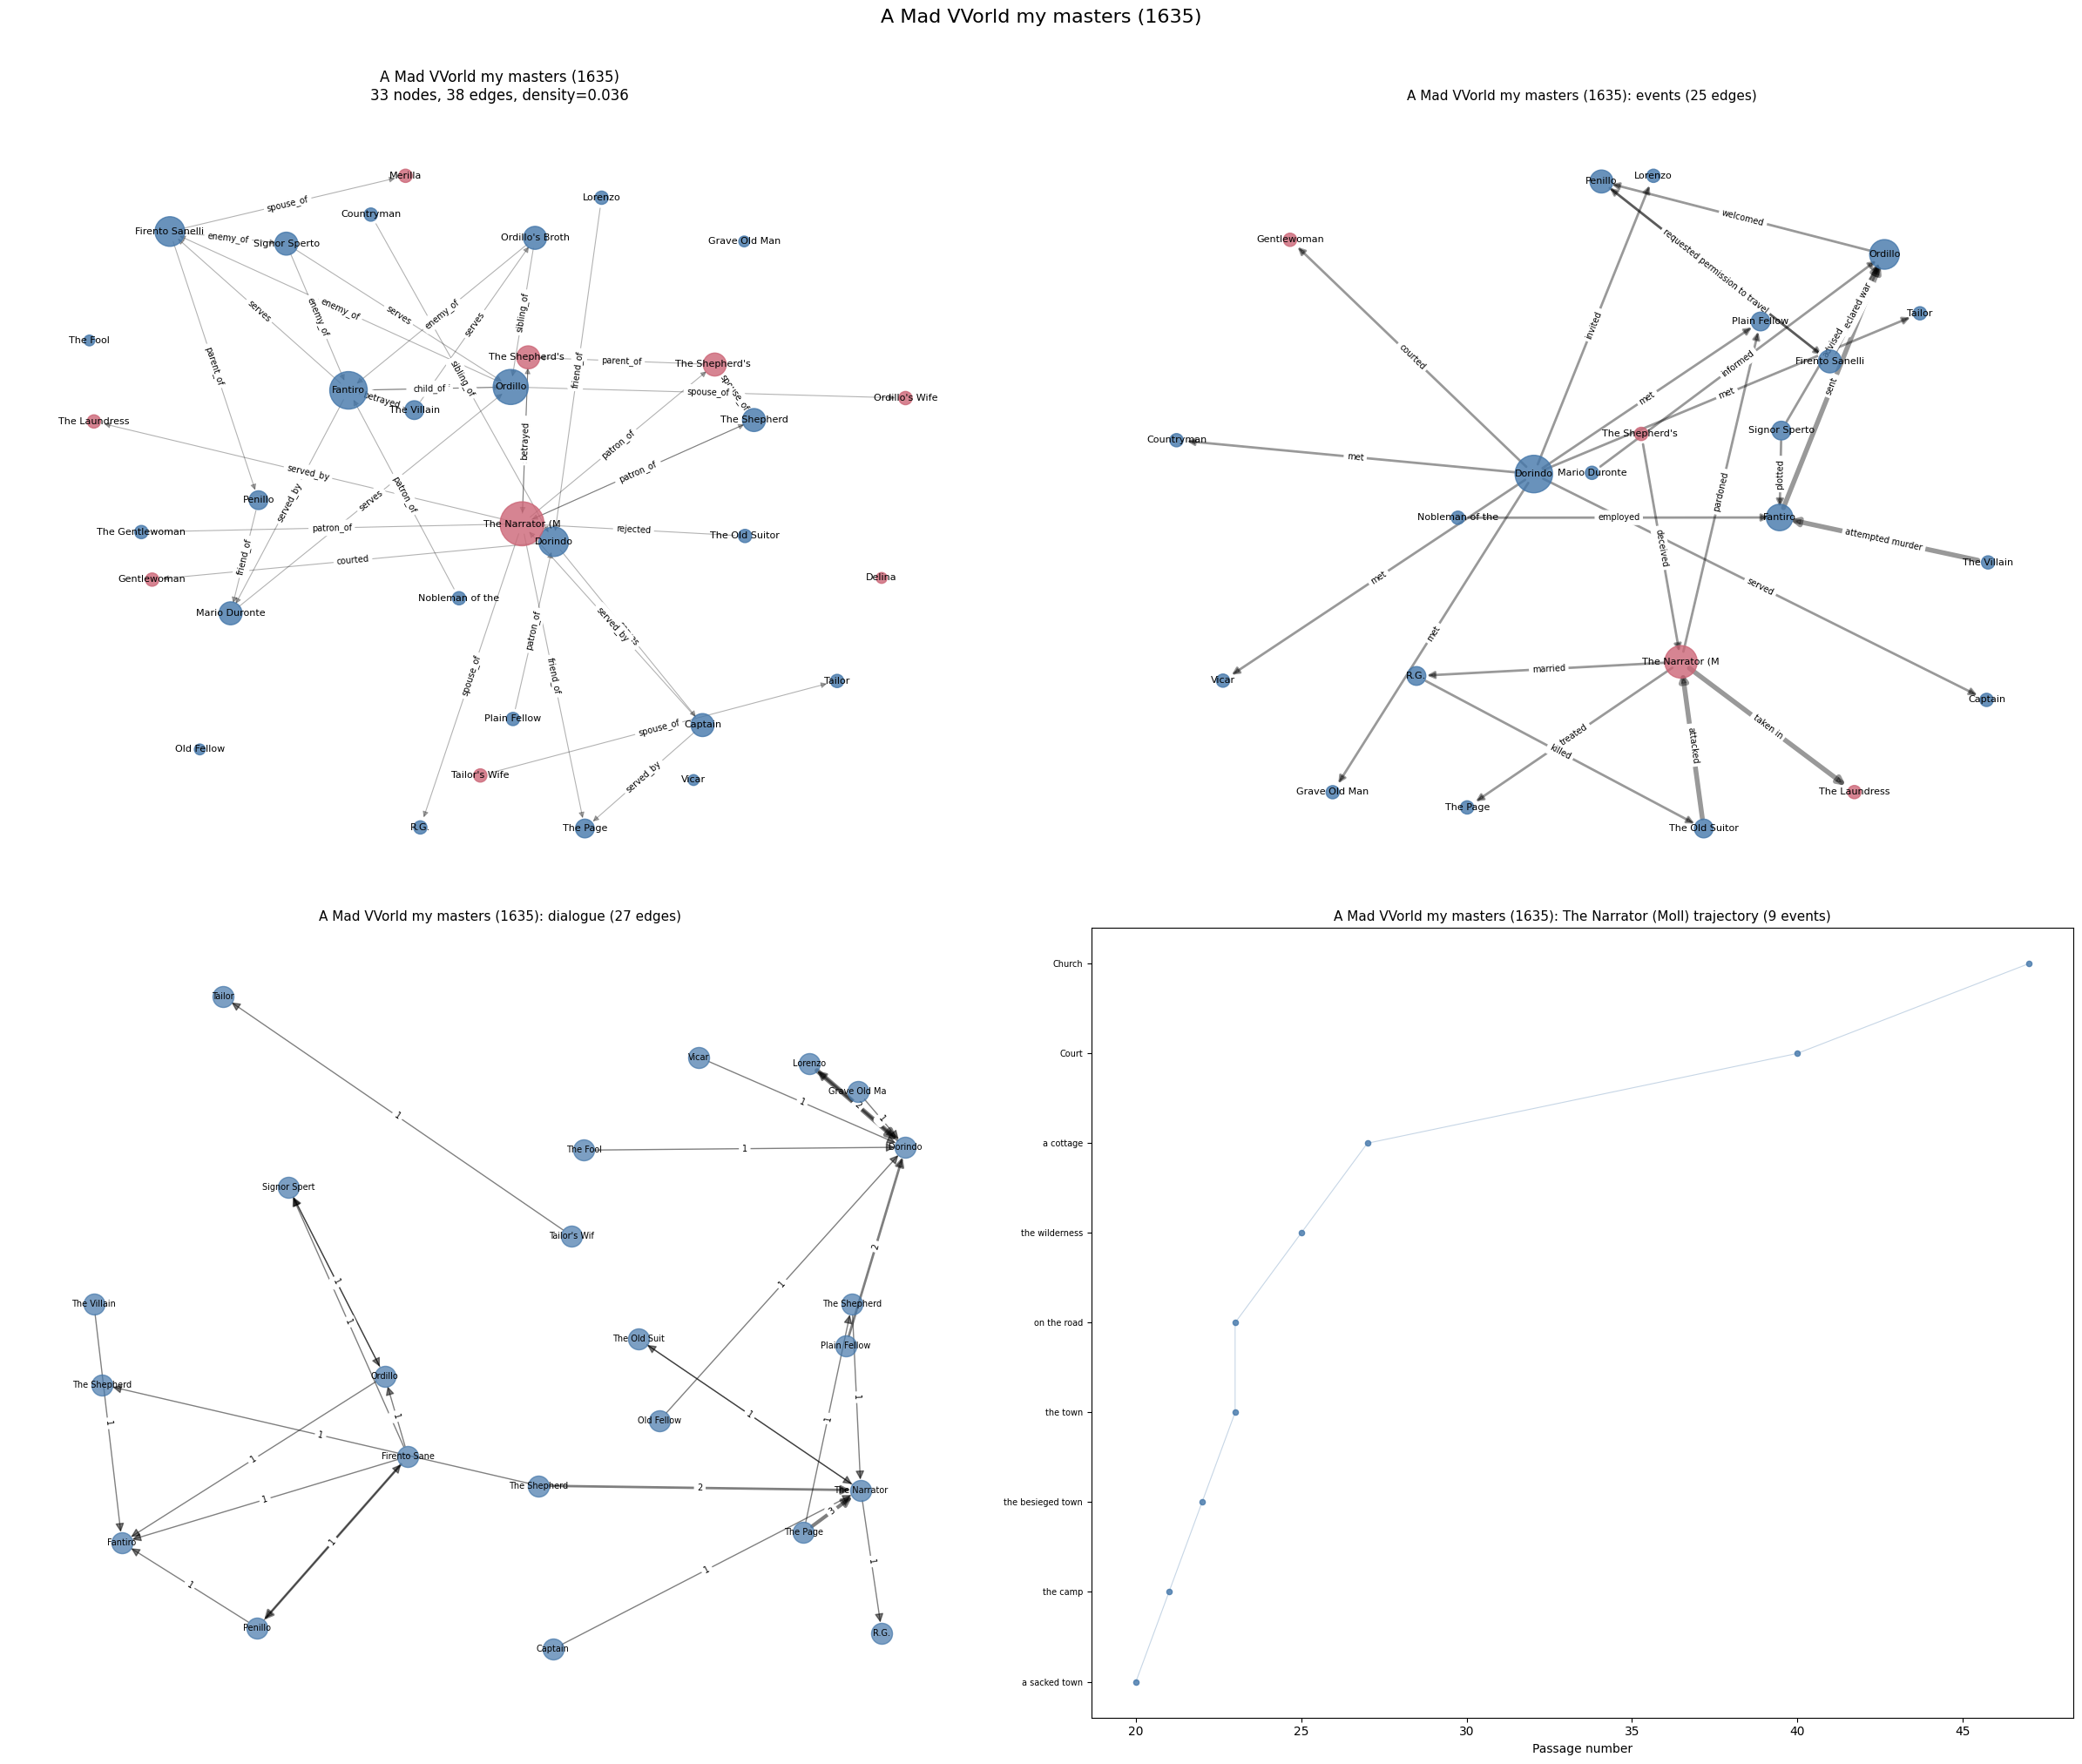

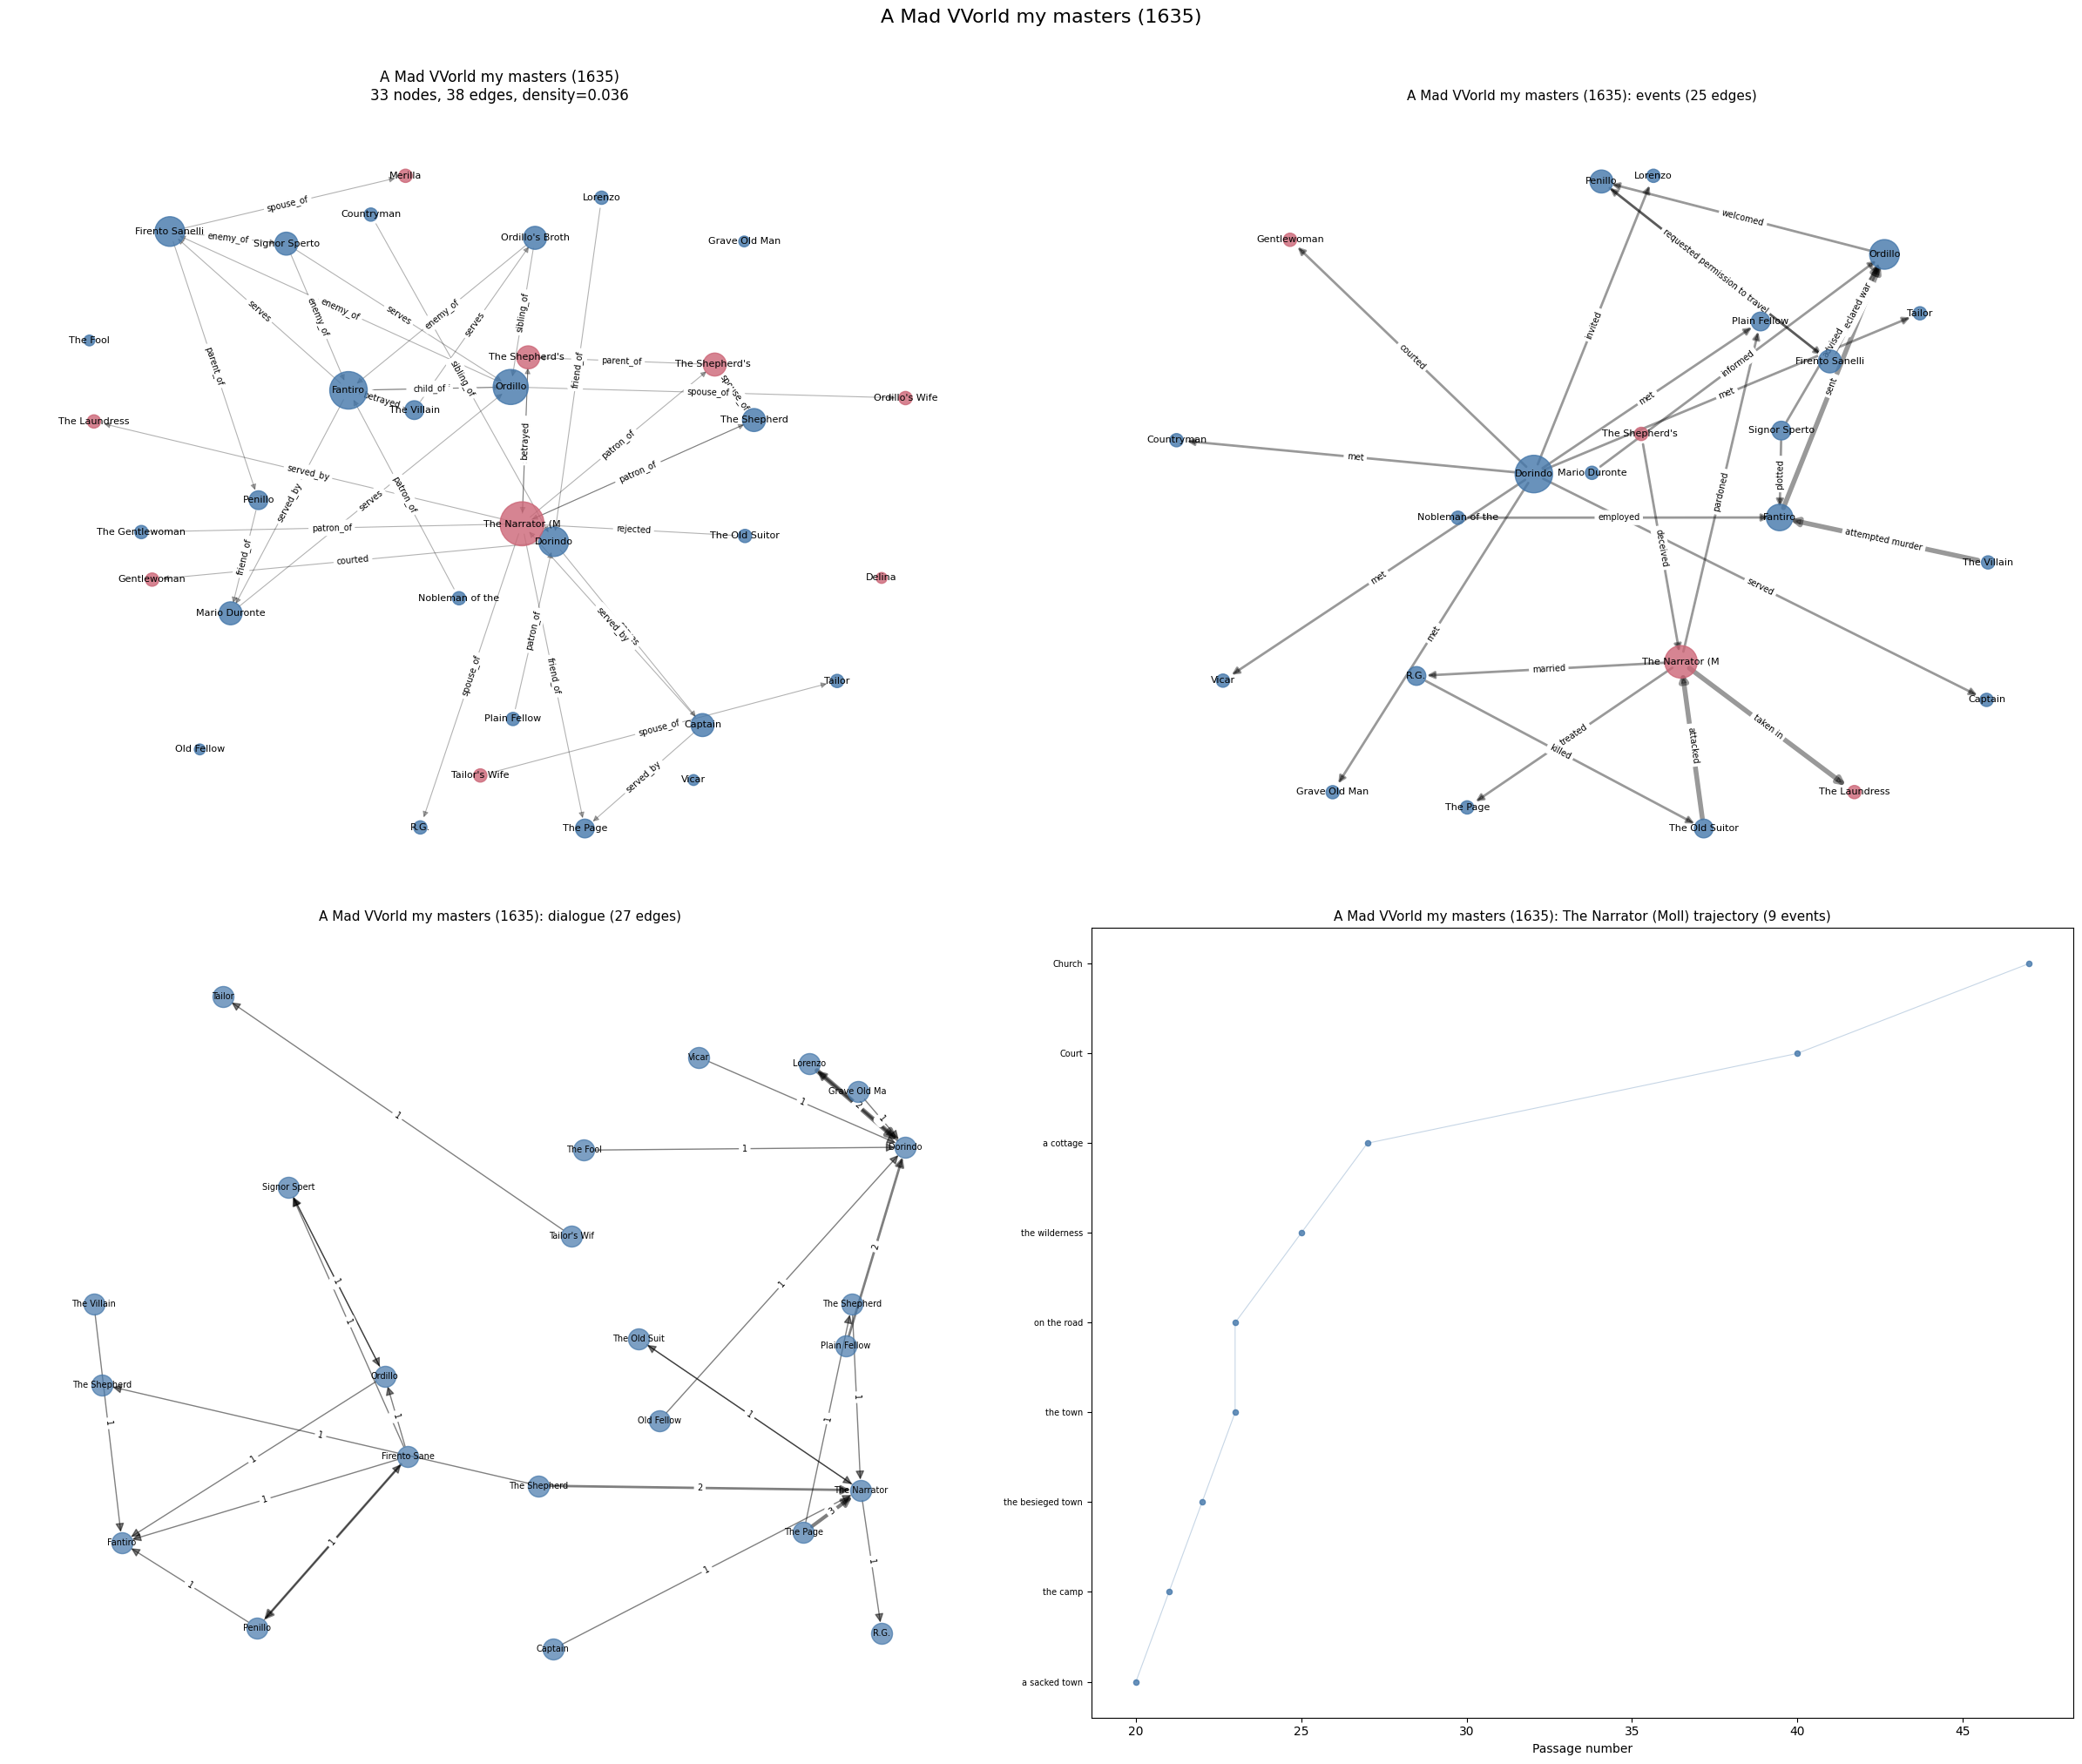

In [196]:
# Composite 2x2 (relations + events + dialogue + trajectory)
sn.plot(color_by='gender', save=f'../figures/social_network.{text.year}.{text.title}.png')